# Assignment 1, Task B: Regression using tree methods.

## The data:
In this QSAR exercise, water solubility of various molecules is to be investigated. The dataset in use is the ESOL Dataset assembled by John Delaney, as provided here: https://huggingface.co/datasets/scikit-fingerprints/MoleculeNet_ESOL/tree/main.


## The tasks:
1) Inspect the data and clean if needed. Adhere to good practices!
2) Calculate some molecular descriptors via the smiles strings using rdkit (partial snippet provided)
3) Create a feature matrix X and a target vector y
4) Three different models should be trained on the molecular descriptors and evaluated according to RMSE and their R2 score to compare their performance. For each model, additionally, the overfitting needs to be addressed.

These three models have to be compared:
- `DecisionTreeRegressor`
- `RandomForestRegressor`
- `GradientBoostingRegressor`

For a first baseline performance, the models can be used as provided by `scikit`, but should include a random seed. 

5) Based on the model performance, take the best performing algorithm and optimise its hyperparameters using `GridSearchCV`

6) Assess the feature importance

7) Conclusion and discussion: Provide answers to the questions.

In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, ConfusionMatrixDisplay

In [288]:
df = pd.read_csv("esol.csv")
df.head()
df.describe()


,label
count,1128.000000
mean,-3.050102
std,2.096441
min,-11.600000
25%,-4.317500
50%,-2.860000
75%,-1.600000
max,1.580000


## 1. Inspect and clean the data
Gain some overview of the data and assess NaNs and duplicates and clean if needed.

In [289]:
df.isna().any()
display(df.duplicated().sum())
df.describe()
df.info()
df.head()

np.int64(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMILES  1128 non-null   object 
 1   label   1128 non-null   float64
dtypes: float64(1), object(1)
memory usage: 17.8+ KB


,SMILES,label
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


## 2. Create molecular descriptors from the Smiles
Use the snippet below to calculate descriptors from the SMILES strings. Make sure to include the molecular weight, the logP and choose three more which you believe to impact the solubility, e.g. https://greglandrum.github.io/rdkit-blog/posts/2022-12-23-descriptor-tutorial.html or here: https://deepwiki.com/rdkit/rdkit/6.1-molecular-descriptors-and-properties 

In [290]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA" : Descriptors.TPSA(mol), 
        "RingCount" : Descriptors.RingCount(mol),
        "HetAt" : Descriptors.NumHeteroatoms(mol)
    })

# Apply to dataframe
descriptor_df = df["SMILES"].apply(compute_descriptors)

# Combine descriptors with original data
df_full = pd.concat([df, descriptor_df], axis=1)

# Remove rows where descriptor calculation failed
df_full = df_full.dropna()
df_full.head()

,SMILES,label,MolWt,LogP,TPSA,RingCount,HetAt
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,202.32,3.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,42.24,2.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,17.07,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,0.00,5.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.00,1.0,1.0


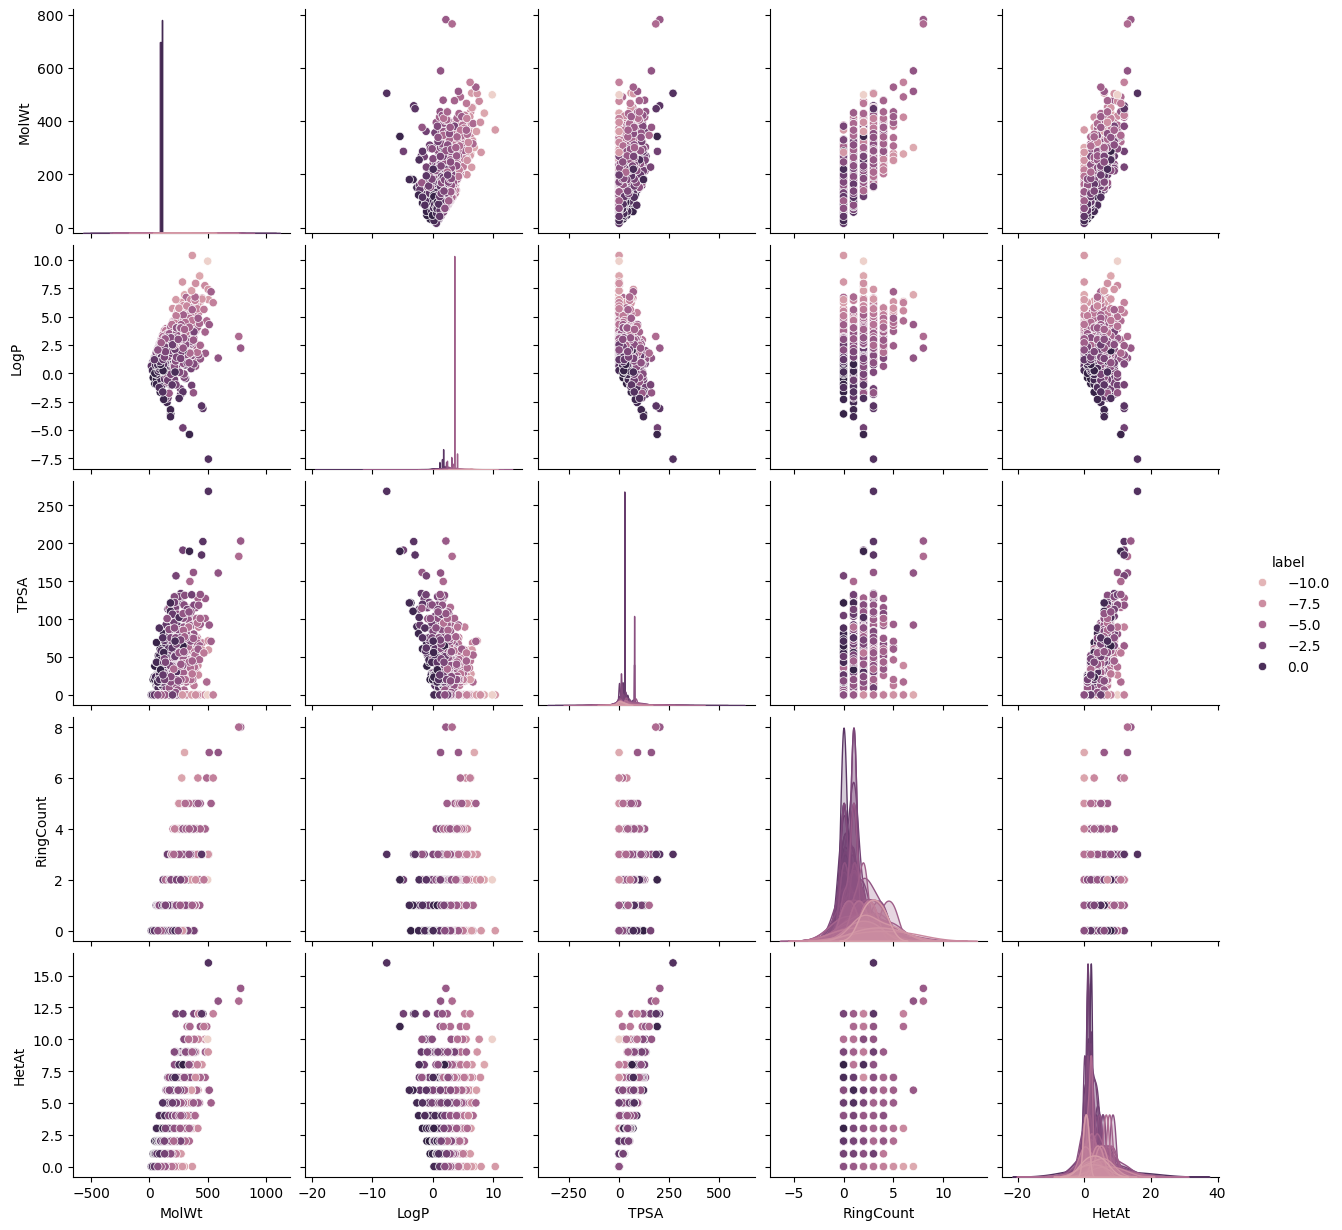

In [291]:
sns.pairplot(data=df_full, hue="label")

## 3. Create the feature matrix and target vector

In [292]:
# Features (X) and target (y)
X = df_full[[
    
    "MolWt",
    "LogP",
    "TPSA",
    "RingCount",
    "HetAt"
]]

y = df_full["label"]

print("Feature matrix shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())
print(X.duplicated().any())

Feature matrix shape: (1128, 5)

Class distribution:
label
-1.960    7
-1.300    6
-0.850    6
-1.600    6
-1.990    5
         ..
-0.985    1
-3.780    1
-1.877    1
-4.770    1
-4.522    1
Name: count, Length: 734, dtype: int64
True


## 4. Train the models
Use a classic train-test split of 0.2 including a random seed. For training and predicting labels, take note of the time the process takes for each model (does not necessarily have to be coded, can also be estimated). Make sure to predict labels for both training and test splits in order to identify overfitting. Use the RMSE and R2 as metrics for evaluation of the baseline performance of the models. Make sure to consider overfitting.

### DecisionTreeRegressor

In [293]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,

)

In [294]:
dtr=DecisionTreeRegressor(random_state=42)
dtr.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [295]:
dtr_y_test_pred = dtr.predict(X_test)
dtr_y_train_pred = dtr.predict(X_train)



In [296]:
dtc_r2 = r2_score(y_test, dtr_y_test_pred)
dtr_rmse =(mean_squared_error(y_test, dtr_y_test_pred))**.5
RMSE=[]
r2=[]
r2.append(dtc_r2)
RMSE.append(dtr_rmse)
print("R2:", dtc_r2)
print("RMSE:", dtr_rmse)



R2: 0.8013173131018946
RMSE: 0.9690892723224573


In [297]:
### training
train_r2=[]
train_rmse=[]


dtr_train_r2 = r2_score(y_train, dtr_y_train_pred)
dtr_train_rmse = (mean_squared_error(y_train, dtr_y_train_pred))**.5


train_r2.append(dtr_train_r2)
train_rmse.append(dtr_train_rmse)

### RandomForestRegressor

In [298]:
rfr=RandomForestRegressor()
rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [299]:
rfr_y_test_pred = rfr.predict(X_test)
rfr_y_train_pred = rfr.predict(X_train)

In [300]:
rfr_r2 = r2_score(y_test, rfr_y_test_pred)
rfr_rmse =(mean_squared_error(y_test, rfr_y_test_pred))**.5

r2.append(rfr_r2)
RMSE.append(rfr_rmse)


In [301]:
### training

rfr_train_r2 = r2_score(y_train, rfr_y_train_pred)
rfr_train_rmse = (mean_squared_error(y_train, rfr_y_train_pred))**.5


train_r2.append(rfr_train_r2)
train_rmse.append(rfr_train_rmse)

### GradientBoostingRegressor

In [302]:
gbr=GradientBoostingRegressor()
gbr.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [303]:
gbr_y_test_pred = gbr.predict(X_test)
gbr_y_train_pred = gbr.predict(X_train)

In [304]:
gbr_r2 = r2_score(y_test, gbr_y_test_pred)
gbr_rmse =(mean_squared_error(y_test, gbr_y_test_pred))**.5

r2.append(gbr_r2)
RMSE.append(gbr_rmse)


In [305]:
### training

gbr_train_r2 = r2_score(y_train, gbr_y_train_pred)
gbr_train_rmse = (mean_squared_error(y_train, gbr_y_train_pred))**.5


train_r2.append(gbr_train_r2)
train_rmse.append(gbr_train_rmse)

### Best model

In [306]:
metrics=[r2, RMSE]
df_metrics = pd.DataFrame(metrics, index=["r2", "RMSE"],columns=["dtr", "rfr", "gbr"])
display(df_metrics)


,dtr,rfr,gbr
r2,0.801317,0.865285,0.870143
RMSE,0.969089,0.797979,0.783459


Use the best model and plot the predictions over the true values (y_test vs. y_pred) in a scatterplot.

using gbr bc lowest vals

Text(0.5, 1.0, 'True vs Predicted')

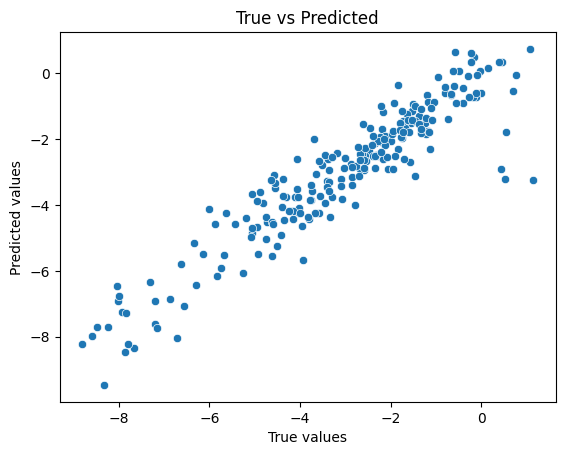

In [307]:
sns.scatterplot(x=y_test, y=rfr_y_test_pred)

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")

Text(0.5, 1.0, 'True vs Predicted')

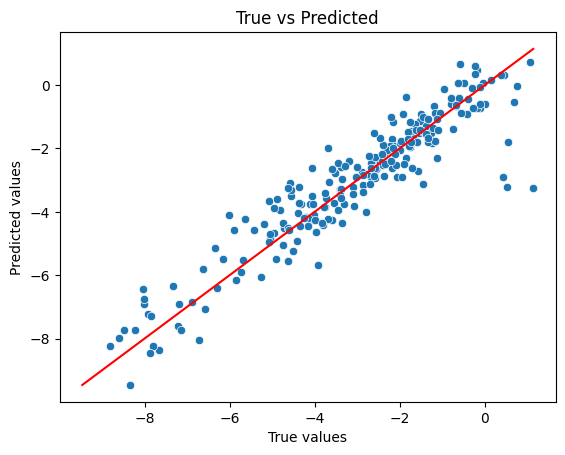

In [308]:

sns.scatterplot(x=y_test, y=rfr_y_test_pred)

# perfect prediction line
min_val = min(y_test.min(), rfr_y_test_pred.min())
max_val = max(y_test.max(), rfr_y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")

## 5. Hyperparameter tuning of the best model
Use GridSearchCV to optimise the hyperparameters for the best model. Use a reasonable parameter grid (2-3 different values max. for each parameter you want to optimise).

In [ ]:
param_grid = {
    "n_estimators": [100, 300],
    "learning_rate": [1],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3]
}



#johannes sols
param_grid = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3]
}

In [310]:
grid_search= GridSearchCV(
    gbr,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [1], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 3], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

Extract the best model

In [311]:
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 1, 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 100}


Useful tool: Export (and reimport) your best model:

In [312]:
import joblib
# export the best model:
joblib.dump(best_model, "best_model.joblib")
# reload the best model:
loaded_model = joblib.load("best_model.joblib")

Evaluate the best model on the test set.

In [313]:


y_pred_tuned = best_model.predict(X_test)
y_train_pred_tuned = best_model.predict(X_train)

tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_rmse =(mean_squared_error(y_test, y_pred_tuned))**.5

r2.append(tuned_r2)
RMSE.append(tuned_rmse)
print("R2:", tuned_r2)
print("RMSE:", tuned_rmse)

print(r2)

R2: 0.8043779279565089
RMSE: 0.9615961172736224
[0.8013173131018946, 0.8652850789937466, 0.8701432717825311, 0.8043779279565089]


In [314]:
###training

"""train_tuned_r2 = r2_score(y_test, y_train_pred_tuned)
train_tuned_rmse =(mean_squared_error(y_test, y_train_pred_tuned))**.5

train_r2.append(train_tuned_r2)
train_rmse.append(train_tuned_rmse)"""

'train_tuned_r2 = r2_score(y_test, y_train_pred_tuned)\ntrain_tuned_rmse =(mean_squared_error(y_test, y_train_pred_tuned))**.5\n\ntrain_r2.append(train_tuned_r2)\ntrain_rmse.append(train_tuned_rmse)'

Plot the predicted vs. the true solubility again!

Text(0.5, 1.0, 'True vs Predicted')

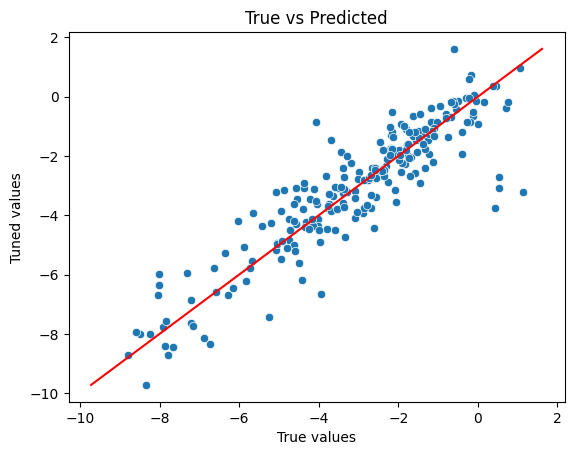

In [315]:
sns.scatterplot(x=y_test, y=y_pred_tuned)

# perfect prediction line
min_val = min(y_test.min(), y_pred_tuned.min())
max_val = max(y_test.max(), y_pred_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.xlabel("True values")
plt.ylabel("Tuned values")
plt.title("True vs Predicted")

In [319]:
metrics=[r2, RMSE]
df_metrics = pd.DataFrame(metrics, index=["r2", "RMSE"],columns=["dtr", "rfr", "gbr", "tuned gbr"])
display(df_metrics)


train_metrics=[train_r2, train_rmse]
df_train_metrics = pd.DataFrame(train_metrics, index=["r2_train", "RMSE_train"],columns=["dtr", "rfr", "gbr"])
display(df_train_metrics)


,dtr,rfr,gbr,tuned gbr
r2,0.801317,0.865285,0.870143,0.804378
RMSE,0.969089,0.797979,0.783459,0.961596


,dtr,rfr,gbr
r2_train,0.996119,0.982983,0.941374
RMSE_train,0.129282,0.270727,0.502494


## 6. Feature importance
Investigate the feature importance for your best model using the snippet below (but with your descriptors).

In [ ]:
feature_names = [
    "MolWt", "LogP",  "TPSA", "RingCount", "HetAt"]

importances = best_model.feature_importances_

for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"{name}: {imp:.3f}")

LogP: 0.828
MolWt: 0.086
TPSA: 0.055
HetAt: 0.023
RingCount: 0.008


## 7. Conclusion and discussion
- Which model performed the best?
- Which model showed the worst overfitting?
- Did the GridSearchCV improve the model? Is the difference to be considered significant?
- Which descriptors (besides the logP) had the most influence on the solubility?


The GradientBoostingRegressor performed the best, the model could expalin 87% of the variance. 

The DecisionTreeRegressor had the worst overfitting

GridSearch CV did not improve the model, had higher errors and lower r2 values than the untuned version. 

Molweight had the second highest influence, surprisingly the number of hetero atoms and Polar surface area didn't have a big influence. Could try with HBD/HBA to see their effect.